# Moored CTD profile - minimal example

📥 Download: [`Moored CTD profile - minimal example.ipynb`](https://github.com/NPIOcean/kval/raw/master/docs/source/examples/notebooks/moored_CTD_minimal_example.ipynb?raw=true)

___

**In this notebook**

- Load `.rsk` data file from RBR Cpnverto.
- Quick overview and showcasinbgf a few basic functions from the `kval.data.moored` odule.

In [1]:
%matplotlib widget

In [2]:
# Import the moored module from kval.data
from kval.data import moored
# Set the plotting backed so we can interact with figures
%matplotlib widget 

## Load data from `.rsk` files into an xarray Dataset

(Note: Functionality for loading `,rsk` files  wraps [`pyrsktools`](https://docs-static.rbr-global.com/pyrsktools/intro.html) from RBR).

`oored.load_moored` loads data from the file into a `Dataset`. We provide lat and lon of teh observations since they are useful for subsequent operations.  

In [3]:
ds = moored.load_moored('../../../../tests/test_data/rbr_files/conc_example.rsk', lat=81, lon = 31)

The xarray Dataset `ds` should contain 1-D variale fields (`TEMP`, `CNDC`, `PRES`, `PSAL`) gridded on a time dimension (`TIME`). There should also be auxiliaru coordinates `LATITUDE` and `LONGITUDE` with the values specified above.

Metadata are brought along in global and variable attributes.


## Have a look at the data


**Take a first  look at the dataset**



To have a look around, run `ds` in a cell and browse (if you are running the notebook interactively). Click the ⛃ and 🗎 symbols on the right to display data and metadata.   

In [4]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:    (TIME: 174156)
Coordinates:
  * TIME       (TIME) float64 1MB 1.888e+04 1.888e+04 ... 1.888e+04 1.888e+04
    LATITUDE   float32 4B 81.0
    LONGITUDE  float32 4B 31.0
Data variables:
    CNDC       (TIME) float64 1MB -0.005038 -0.005657 ... -0.005014 -0.004107
    TEMP       (TIME) float64 1MB -6.506 -6.547 -6.559 ... -3.178 -2.736 -2.382
    PRES       (TIME) float64 1MB 0.1187 0.1128 0.117 ... -0.02908 -0.03651
    PSAL       (TIME) float64 1MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    instrument_model:          RBRconcerto³
    instrument_serial_number:  201401
    time_coverage_resolution:  P0000-00-00T00:00:01
    sampling_details:          Continuous sampling - one measurement every 1 sec
    source_file:               conc_example.rsk
    history:                   2021-09-11 - 2021-09-13: Data collection.\n202...

#### Quick plot of the time series

To quickly inspect the time series, use `mored.plot`

In [5]:
moored.plot(ds)

### Remove deck time

Try to automatically detect deck time and cut it away from the dataset.

Running with no argument will suggest a cut; make sure to inspect it. Yfromou can always specify yourself if you are not happy with the result.

In [6]:
ds = moored.chop_deck(ds, indices=(13, 174000))

Chopping to idx: (13, 174000)
Chopped 168 samples using -> (13, 174000) (total samples 174156 -> 173988)


### Chop by time

Note above that CNDC/PSAL data look questionable in parts of the record, let's chop parts of the record away:


In [7]:
ds = moored.chop_by_time(ds, start_time = '2021-09-11 23:30', end_time ='2021-09-13 11:00')

Chopped dataset to time range 2021-09-11 23:30 to 2021-09-13 11:00, reducing from 173988 to 127860 samples.


### Despike

`kval.moored` contains many functions for filtering, outlier removal, drift correction, threshold-passing, etc.

To test one function, we noted a clear outlier in `PRES`. Let's try to remove it automatically: 

The function below flags points exceetid 4 standard deviation from teh 1501-point running median. These are parameters that typically have to be tuned based on instrument, sampling rate, etc.


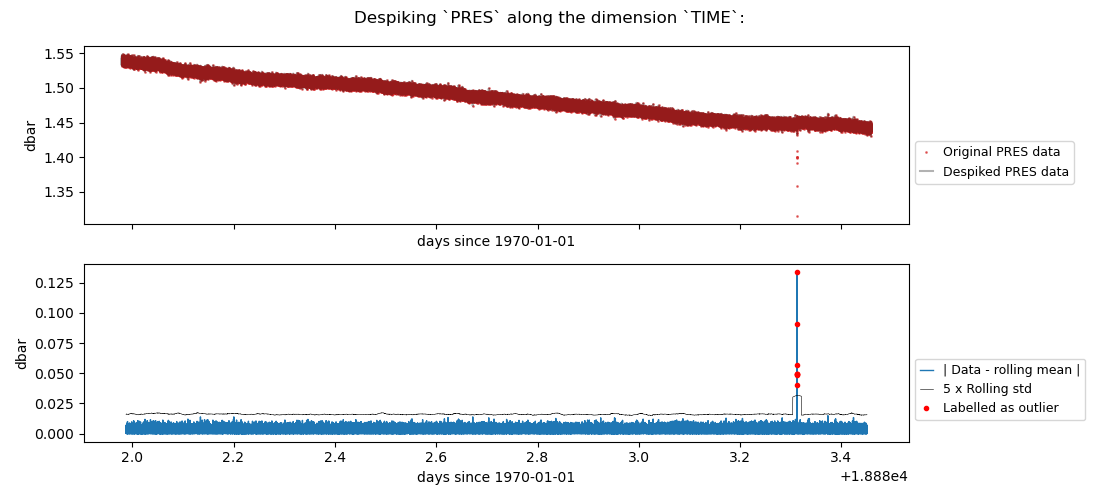

In [8]:
ds = moored.despike_rolling(ds, 'PRES', 1501, 5, plot=True)

In [9]:
moored.plot(ds)

#### T-S plot

In [10]:
moored.tsplot_pick(ds, )

A note on interpretation: These data were collected right below sea ice in freezing temperatures, so we expect measurements very near the surface freezing temperature. This could point toward an issue with a sensor (althogu noter that the T and S ranges are very small here, and functionally very close to the freezing line).